In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")



In [ ]:
df = pd.read_csv("diabetes (6).csv")
print("Shape: ",df.shape)

Shape:  (768, 9)


In [ ]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# head tail shape columns dtypes info() describe isnull.issum duplicates.sum   box plot piechart/count plot , hist , scatter heatmap

In [ ]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin","BMI"]
zero_counts = (df[zero_columns] == 0).sum()
print("Zero values:")
print(zero_counts)

Zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
df_clean = df.copy()
df_clean[zero_columns] = df_clean[zero_columns].replace(0, np.nan)
print("Missing values after replacing invalid zeroes:")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeroes:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
for col in zero_columns:
  df_clean[col] = df_clean[col].fillna(df_clean[col].median())
  print("Missing values after median imputation:")
  print(df_clean.isnull().sum())

Missing values after median imputation:
Pregnancies                   0
Glucose                       0
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Missing values after median imputation:
Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Missing values after median imputation:
Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome               

In [ ]:
X = df_clean.drop("Outcome",axis=1)
y = df_clean["Outcome"]
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (768, 8)
y shape:  (768,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])

Training samples: 614
Testing samples: 154


In [ ]:
print("Training Distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting Distribution:")
print(y_test.value_counts(normalize=True))

Training Distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing Distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler.fit_transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [ ]:
scaler.transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [ ]:
comparison = pd.DataFrame({
    "Original mean": X_train.mean(),
    "Original std": X_train.std(),
    "Scaled mean": X_train_scaled.mean(axis=0),
    "Scaled std": X_train_scaled.std(axis=0)
})
display(comparison)

,Original mean,Original std,Scaled mean,Scaled std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [ ]:
K = 5


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test_scaled)
print("Predictions: ")
print(y_pred[:20])

Predictions: 
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [ ]:
y_prob = knn.predict_proba(X_test_scaled)[:, 1]
print(y_prob[:20])

[0.6 0.2 0.2 0.6 0.  0.2 0.2 0.8 0.  0.6 0.4 0.6 0.  0.  0.  0.6 0.8 0.
 1.  0.2]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7532
Precision: 0.6600
Recall: 0.6111
F1 Score: 0.6346


In [ ]:
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[83 17]
 [21 33]]


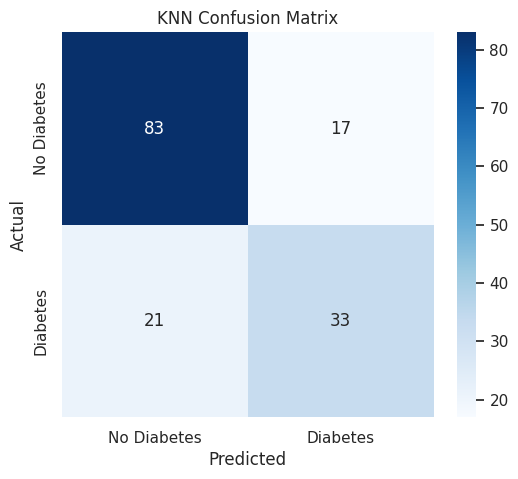

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
k_values = range(1, 31)
train_accuracy = []
test_accuracy = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_accuracy.append(model.score(X_train_scaled, y_train))
    test_accuracy.append(model.score(X_test_scaled, y_test))

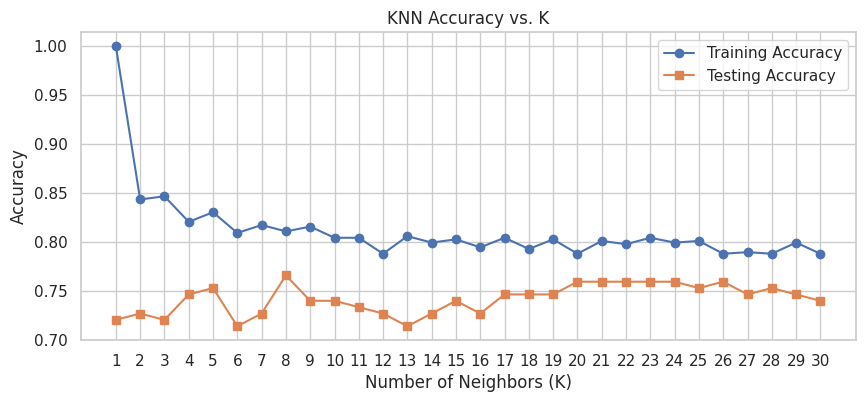

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(k_values, train_accuracy,marker="o", label="Training Accuracy")
plt.plot(k_values, test_accuracy,marker="s", label="Testing Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs. K")
plt.xticks(k_values)
plt.legend()
plt.show()

In [ ]:
best_k_accuracy = k_values[np.argmax(test_accuracy)]
best_accuracy = max(test_accuracy)
print("Best K: ",best_k_accuracy)
print("Best Test Accuracy: ",best_accuracy)

Best K:  8
Best Test Accuracy:  0.7662337662337663


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for k in range(1, 31):
  model = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
  cv_scores.append(scores.mean())

In [ ]:
best_k_cv = np.argmax(cv_scores) + 1
print("Best K based on Cross Validation:", best_k_cv)
print("Best CV Accuracy:", max(cv_scores))

Best K based on Cross Validation: 13
Best CV Accuracy: 0.7703718512594963


In [ ]:
param_grid = {"n_neighbors": list(range(3, 31, 2)), "weights": ["uniform", "distance"],
              "metric": ["euclidean", "manhattan", "minkowski"],
              "p": [1,2]}


In [ ]:
grid_search  = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print("Grid Search completed.")

Grid Search completed.


In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}
Best Accuracy: 0.7769025723044115


In [ ]:
best_knn = grid_search.best_estimator_
print(best_knn)

KNeighborsClassifier(metric='euclidean', n_neighbors=19, p=1)


In [ ]:
final_pred = best_knn.predict(X_test_scaled)
final_prob = best_knn.predict_proba(X_test_scaled)[:, 1]

In [ ]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
print(f"Final Accuracy: {final_accuracy:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final Recall: {final_recall:.4f}")
print(f"Final F1 Score: {final_f1:.4f}")

Final Accuracy: 0.7468
Final Precision: 0.6667
Final Recall: 0.5556
Final F1 Score: 0.6061
